# MWE 36 - Trabecular bone slice porosity and permeability maps

This notebook turns one 2-D slice of the trabecular-bone RAW segmentation into
continuum maps that can be passed to a solver workflow:

- a marrow-space porosity map, computed as block-averaged local void fraction
- a Kozeny-Carman permeability map on the same coarse cells
- HDF5 map exports with metadata
- structured quad- and triangle-mesh exports for Gmsh/VTK-style workflows

The source image is the same RAW segmentation used in
`35_mwe_trabecular_bone_morphometry`.

Scientific scope and assumptions:

- the RAW filename convention is interpreted as `0_poro` = marrow/pore and
  `1_osso` = bone
- the RAW byte count matches a `(350, 350, 349)` `uint8` array, not the
  nominal `300 x 300 x 300` in the filename
- the axis order is still a RAW provenance assumption because there is no
  sidecar header
- a single 2-D slice cannot measure 3-D absolute permeability; the
  permeability field below is a closure-based local coefficient
- the generated meshes are the regular porosity-map grid, not a
  bone/marrow-interface conforming segmentation mesh

The Gmsh, VTK, and VTU files carry floating cell data through `meshio`. The
Netgen `.vol` export is geometry-oriented in `meshio`, so the HDF5 maps remain
the authoritative porosity/permeability field export for Netgen workflows.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import meshio
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.image.porosity import (
    load_permeability_map_hdf5,
    load_porosity_map_hdf5,
    permeability_map_from_porosity,
    porosity_map_from_binary,
    save_permeability_map_hdf5,
    save_porosity_map_hdf5,
)
from voids.mesh import write_structured_map_meshes
from voids.paths import data_path, project_root

In [2]:
# User-editable inputs
raw_relpath = Path("trabecular-image") / "Trabecular_300_cubo_0_poro_1_osso_2086nm.raw"
raw_dtype = np.uint8
raw_shape = (350, 350, 349)
raw_order = "C"

bone_value = 1
marrow_value = 0
axis_labels = ("x", "y", "z")

# Central XY slice by default. Change `slice_axis` and `slice_index` together if
# a different anatomical plane is needed.
slice_axis = 2
slice_index: int | None = None

voxel_size_nm = 2086.0
voxel_size_m = voxel_size_nm * 1.0e-9
block_shape = (5, 5)

# Kozeny-Carman closure parameters. These are deliberately editable because they
# are model assumptions, not measurements from a single slice.
kozeny_constant = 180.0
solid_permeability_m2 = 1.0e-20
free_flow_permeability_m2 = 1.0e-8
max_permeability_m2 = 1.0e-8

mesh_formats = ("gmsh", "vtk", "vtu", "netgen")
triangle_mesh_formats = ("gmsh", "vtk", "vtu")

output_dir = (
    project_root()
    / "notebooks"
    / "outputs"
    / ("36_mwe_trabecular_bone_slice_porosity_permeability_maps")
)
output_dir.mkdir(parents=True, exist_ok=True)
output_dir

PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/36_mwe_trabecular_bone_slice_porosity_permeability_maps')

## Load one segmented slice

The image is loaded as a memory map so selecting a single slice does not
require materializing the full 3-D image. The byte-count check guards against a
silent RAW shape mismatch.

In [3]:
raw_path = data_path() / raw_relpath
if not raw_path.exists():
    raise FileNotFoundError(
        f"Missing trabecular RAW volume at {raw_path}. "
        "Run from the repository root or set VOIDS_DATA_PATH."
    )

expected_voxels = int(np.prod(np.asarray(raw_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(raw_dtype).itemsize
if expected_voxels != actual_voxels:
    raise ValueError(
        f"Configured shape {raw_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}."
    )

if not 0 <= slice_axis < len(raw_shape):
    raise ValueError(f"slice_axis must be in [0, {len(raw_shape) - 1}]")
resolved_slice_index = (
    raw_shape[slice_axis] // 2 if slice_index is None else int(slice_index)
)
if not 0 <= resolved_slice_index < raw_shape[slice_axis]:
    raise ValueError(
        f"slice_index must be in [0, {raw_shape[slice_axis] - 1}] for axis {slice_axis}"
    )

raw_image = np.memmap(
    raw_path,
    dtype=raw_dtype,
    mode="r",
    shape=raw_shape,
    order=raw_order,
)

slice_image = np.asarray(np.take(raw_image, resolved_slice_index, axis=slice_axis))
values, counts = np.unique(slice_image, return_counts=True)
if set(values.tolist()) - {marrow_value, bone_value}:
    raise ValueError(
        "This notebook expects a binary segmentation with only the configured "
        f"marrow/bone values {marrow_value!r}/{bone_value!r}."
    )

marrow_slice = slice_image == marrow_value
bone_slice = slice_image == bone_value
slice_axes = tuple(i for i in range(3) if i != slice_axis)
slice_axis_labels = tuple(axis_labels[i] for i in slice_axes)

slice_summary = pd.DataFrame(
    {
        "raw_value": values.astype(int),
        "voxel_count": counts.astype(np.int64),
        "fraction": counts / counts.sum(),
    }
)

print(f"RAW path: {raw_path}")
print(f"Using shape: {raw_shape}")
print(f"Slice plane axes: {slice_axis_labels}")
print(f"Slice normal: {axis_labels[slice_axis]}")
print(f"Slice index: {resolved_slice_index}")
print(f"Voxel size: {voxel_size_m:.6e} m")
display(slice_summary)

RAW path: /Users/dtvolpatto/Work/voids/examples/data/trabecular-image/Trabecular_300_cubo_0_poro_1_osso_2086nm.raw
Using shape: (350, 350, 349)
Slice plane axes: ('x', 'y')
Slice normal: z
Slice index: 174
Voxel size: 2.086000e-06 m


,raw_value,voxel_count,fraction
0,0,99569,0.812808
1,1,22931,0.187192


PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/36_mwe_trabecular_bone_slice_porosity_permeability_maps/trabecular_bone_slice_masks.png')

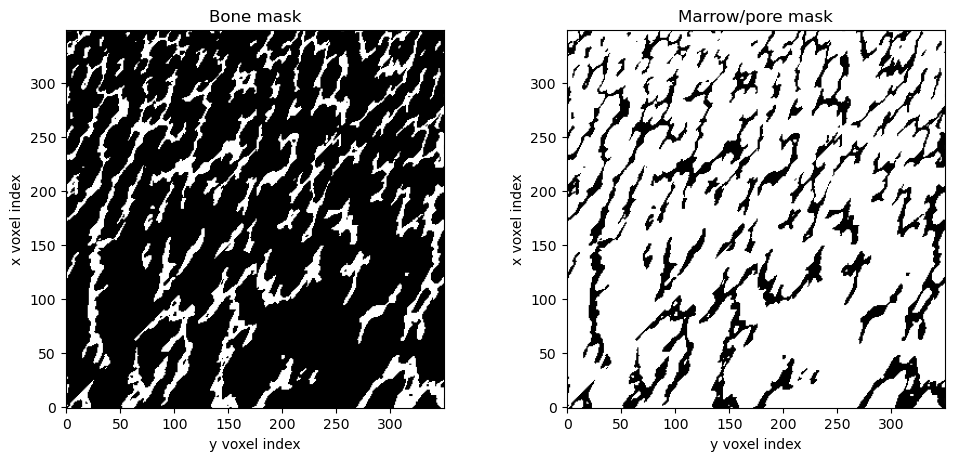

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

axes[0].imshow(bone_slice, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[0].set_title("Bone mask")
axes[0].set_xlabel(f"{slice_axis_labels[1]} voxel index")
axes[0].set_ylabel(f"{slice_axis_labels[0]} voxel index")

axes[1].imshow(marrow_slice, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[1].set_title("Marrow/pore mask")
axes[1].set_xlabel(f"{slice_axis_labels[1]} voxel index")
axes[1].set_ylabel(f"{slice_axis_labels[0]} voxel index")

slice_figure_path = output_dir / "trabecular_bone_slice_masks.png"
fig.savefig(slice_figure_path, dpi=180)
slice_figure_path

## Compute a local porosity map

`porosity_map_from_binary` interprets `True` as void by default. Here the void
phase is marrow/pore space. With the default `block_shape=(10, 10)`, the
`350 x 350` slice becomes a `35 x 35` porosity grid.

In [5]:
porosity_map = porosity_map_from_binary(
    marrow_slice,
    block_shape=block_shape,
    voxel_size=(voxel_size_m, voxel_size_m),
    strict=True,
    metadata={
        "case": "trabecular_bone_slice",
        "raw_relpath": str(raw_relpath),
        "raw_shape": raw_shape,
        "raw_order": raw_order,
        "slice_axis": axis_labels[slice_axis],
        "slice_axis_index": slice_axis,
        "slice_index": resolved_slice_index,
        "slice_axes": slice_axis_labels,
        "phase_convention": "0=marrow_or_pore, 1=bone",
    },
)

global_slice_porosity = float(marrow_slice.mean())
porosity_summary = pd.DataFrame(
    [
        {
            "quantity": "slice marrow fraction",
            "value": global_slice_porosity,
            "units": "-",
        },
        {
            "quantity": "porosity-map mean",
            "value": porosity_map.mean_porosity,
            "units": "-",
        },
        {
            "quantity": "porosity-map cells",
            "value": int(np.prod(porosity_map.shape)),
            "units": "cells",
        },
        {
            "quantity": "cell size along first slice axis",
            "value": porosity_map.cell_size[0],
            "units": porosity_map.units["length"],
        },
        {
            "quantity": "cell size along second slice axis",
            "value": porosity_map.cell_size[1],
            "units": porosity_map.units["length"],
        },
    ]
)

assert np.isclose(porosity_map.mean_porosity, global_slice_porosity)
display(porosity_summary)

,quantity,value,units
0,slice marrow fraction,0.812808,-
1,porosity-map mean,0.812808,-
2,porosity-map cells,4900.000000,cells
3,cell size along first slice axis,0.000010,m
4,cell size along second slice axis,0.000010,m


## Generate a Kozeny-Carman permeability map

The characteristic length is set to the porosity-cell size by default. For
trabecular bone this is only a transparent modeling placeholder; changing
`characteristic_length_m`, `kozeny_constant`, and the endpoint caps can move
the permeability map by orders of magnitude.

In [6]:
characteristic_length_m = min(porosity_map.cell_size)
permeability_map = permeability_map_from_porosity(
    porosity_map,
    characteristic_length=characteristic_length_m,
    kozeny_constant=kozeny_constant,
    solid_permeability=solid_permeability_m2,
    free_flow_permeability=free_flow_permeability_m2,
    max_permeability=max_permeability_m2,
    metadata={
        "closure_note": "Kozeny-Carman map for continuum-coefficient export",
        "scientific_caveat": "not a direct 3D permeability solve from a 2D slice",
    },
)

permeability_values = permeability_map.values
permeability_summary = pd.DataFrame(
    [
        {
            "quantity": "characteristic length",
            "value": characteristic_length_m,
            "units": "m",
        },
        {
            "quantity": "finite mean permeability",
            "value": permeability_map.finite_mean_permeability,
            "units": permeability_map.units["permeability"],
        },
        {
            "quantity": "minimum permeability",
            "value": float(np.min(permeability_values)),
            "units": permeability_map.units["permeability"],
        },
        {
            "quantity": "maximum permeability",
            "value": float(np.max(permeability_values)),
            "units": permeability_map.units["permeability"],
        },
    ]
)
display(permeability_summary)

,quantity,value,units
0,characteristic length,1.043000e-05,m
1,finite mean permeability,5.792730e-09,m^2
2,minimum permeability,1.000000e-20,m^2
3,maximum permeability,1.000000e-08,m^2


PosixPath('/Users/dtvolpatto/Work/voids/notebooks/outputs/36_mwe_trabecular_bone_slice_porosity_permeability_maps/trabecular_bone_slice_porosity_permeability_maps.png')

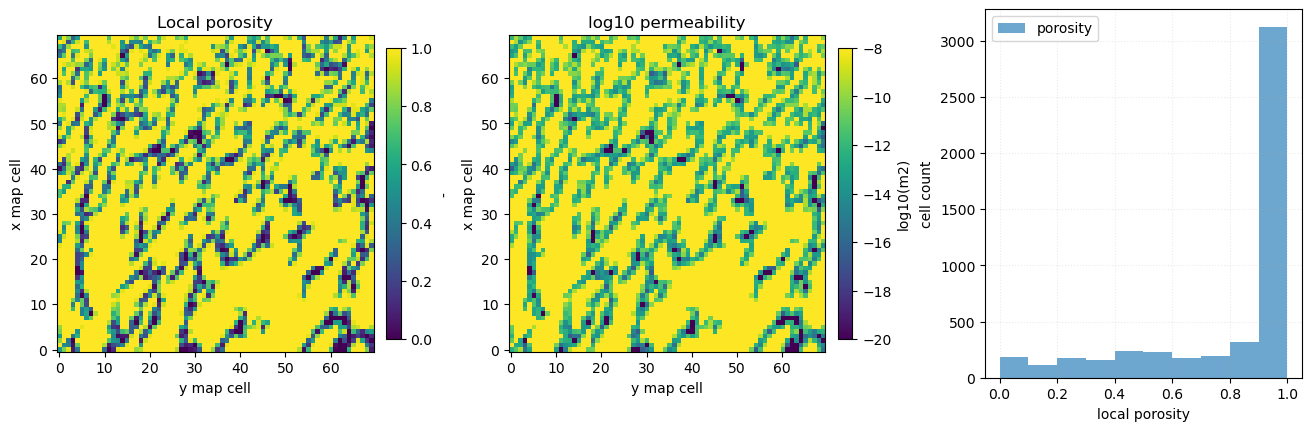

In [7]:
with np.errstate(divide="ignore"):
    log10_permeability = np.log10(permeability_values)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

im = axes[0].imshow(porosity_map.values, origin="lower", vmin=0.0, vmax=1.0)
axes[0].set_title("Local porosity")
axes[0].set_xlabel(f"{slice_axis_labels[1]} map cell")
axes[0].set_ylabel(f"{slice_axis_labels[0]} map cell")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="-")

finite_log = log10_permeability[np.isfinite(log10_permeability)]
im = axes[1].imshow(
    log10_permeability,
    origin="lower",
    vmin=float(np.min(finite_log)),
    vmax=float(np.max(finite_log)),
)
axes[1].set_title("log10 permeability")
axes[1].set_xlabel(f"{slice_axis_labels[1]} map cell")
axes[1].set_ylabel(f"{slice_axis_labels[0]} map cell")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="log10(m2)")

axes[2].hist(porosity_map.values.ravel(), alpha=0.65, label="porosity")
axes[2].set_xlabel("local porosity")
axes[2].set_ylabel("cell count")
axes[2].grid(alpha=0.25, linestyle=":")
axes[2].legend()

map_figure_path = output_dir / "trabecular_bone_slice_porosity_permeability_maps.png"
fig.savefig(map_figure_path, dpi=180)
map_figure_path

## Export maps and structured meshes

The HDF5 files are the solver-neutral map exports. The mesh exports use a
structured quad grid and a triangle subdivision of that grid. In both cases,
cell data follows `porosity_map.values.ravel("C")`; each triangle inherits
the porosity and permeability of its parent map cell. Gmsh `.msh`, VTK
`.vtk`, and VTU `.vtu` preserve the floating cell fields in this workflow.
The Netgen `.vol` file is still useful as geometry, but the continuous fields
should be taken from HDF5 or a format that preserves cell data.

In [8]:
porosity_h5 = output_dir / "trabecular_bone_slice_porosity_map.h5"
permeability_h5 = output_dir / "trabecular_bone_slice_permeability_map.h5"
summary_csv = output_dir / "trabecular_bone_slice_map_summary.csv"

save_porosity_map_hdf5(porosity_map, porosity_h5)
save_permeability_map_hdf5(permeability_map, permeability_h5)

loaded_porosity = load_porosity_map_hdf5(porosity_h5)
loaded_permeability = load_permeability_map_hdf5(permeability_h5)

assert np.allclose(loaded_porosity.values, porosity_map.values)
assert np.allclose(loaded_permeability.values, permeability_map.values)
assert loaded_porosity.cell_size == porosity_map.cell_size
assert loaded_permeability.cell_size == permeability_map.cell_size

mesh_paths = write_structured_map_meshes(
    porosity_map,
    output_dir,
    stem="trabecular_bone_slice_maps",
    permeability_map=permeability_map,
    formats=mesh_formats,
)
triangle_mesh_paths = write_structured_map_meshes(
    porosity_map,
    output_dir,
    stem="trabecular_bone_slice_triangle_maps",
    permeability_map=permeability_map,
    formats=triangle_mesh_formats,
    element_type="triangle",
)

combined_summary = pd.concat(
    [
        porosity_summary.assign(section="porosity"),
        permeability_summary.assign(section="permeability"),
    ],
    ignore_index=True,
)
combined_summary.to_csv(summary_csv, index=False)

mesh_checks: list[dict[str, object]] = []
mesh_path_groups = {"quad": mesh_paths, "triangle": triangle_mesh_paths}
for mesh_family, paths in mesh_path_groups.items():
    for fmt, path in paths.items():
        loaded_mesh = meshio.read(path)
        cell_data_names = sorted(loaded_mesh.cell_data.keys())
        mesh_checks.append(
            {
                "mesh_family": mesh_family,
                "format": fmt,
                "path": str(path.relative_to(project_root())),
                "cell_type": loaded_mesh.cells[0].type,
                "cell_count": int(len(loaded_mesh.cells[0].data)),
                "has_porosity_cell_data": "porosity" in cell_data_names,
                "has_permeability_cell_data": "permeability" in cell_data_names,
                "cell_data_names": ", ".join(cell_data_names),
            }
        )

exports = pd.DataFrame(
    [
        {
            "artifact": "porosity map HDF5",
            "path": str(porosity_h5.relative_to(project_root())),
        },
        {
            "artifact": "permeability map HDF5",
            "path": str(permeability_h5.relative_to(project_root())),
        },
        {
            "artifact": "summary CSV",
            "path": str(summary_csv.relative_to(project_root())),
        },
        {
            "artifact": "slice masks figure",
            "path": str(slice_figure_path.relative_to(project_root())),
        },
        {
            "artifact": "map figure",
            "path": str(map_figure_path.relative_to(project_root())),
        },
        *[
            {
                "artifact": f"{fmt} structured {mesh_family} mesh",
                "path": str(path.relative_to(project_root())),
            }
            for mesh_family, paths in mesh_path_groups.items()
            for fmt, path in paths.items()
        ],
    ]
)

display(exports)
display(pd.DataFrame(mesh_checks))

,artifact,path
0,porosity map HDF5,notebooks/outputs/36_mwe_trabecular_bone_slice...
1,permeability map HDF5,notebooks/outputs/36_mwe_trabecular_bone_slice...
2,summary CSV,notebooks/outputs/36_mwe_trabecular_bone_slice...
3,slice masks figure,notebooks/outputs/36_mwe_trabecular_bone_slice...
4,map figure,notebooks/outputs/36_mwe_trabecular_bone_slice...
5,gmsh structured quad mesh,notebooks/outputs/36_mwe_trabecular_bone_slice...
6,vtk structured quad mesh,notebooks/outputs/36_mwe_trabecular_bone_slice...
7,vtu structured quad mesh,notebooks/outputs/36_mwe_trabecular_bone_slice...
8,netgen structured quad mesh,notebooks/outputs/36_mwe_trabecular_bone_slice...
9,gmsh structured triangle mesh,notebooks/outputs/36_mwe_trabecular_bone_slice...


,mesh_family,format,path,cell_type,cell_count,has_porosity_cell_data,has_permeability_cell_data,cell_data_names
0,quad,gmsh,notebooks/outputs/36_mwe_trabecular_bone_slice...,quad,4900,True,True,"cell_index, gmsh:geometrical, permeability, po..."
1,quad,vtk,notebooks/outputs/36_mwe_trabecular_bone_slice...,quad,4900,True,True,"cell_index, permeability, porosity"
2,quad,vtu,notebooks/outputs/36_mwe_trabecular_bone_slice...,quad,4900,True,True,"cell_index, permeability, porosity"
3,quad,netgen,notebooks/outputs/36_mwe_trabecular_bone_slice...,quad,4900,False,False,netgen:index
4,triangle,gmsh,notebooks/outputs/36_mwe_trabecular_bone_slice...,triangle,9800,True,True,"cell_index, gmsh:geometrical, permeability, po..."
5,triangle,vtk,notebooks/outputs/36_mwe_trabecular_bone_slice...,triangle,9800,True,True,"cell_index, permeability, porosity"
6,triangle,vtu,notebooks/outputs/36_mwe_trabecular_bone_slice...,triangle,9800,True,True,"cell_index, permeability, porosity"


## Interpretation notes

The map mean matches the slice marrow fraction because the slice dimensions
are exactly divisible by `block_shape`. That is a useful conservation check,
but it does not validate the permeability closure. For real solver studies,
the main remaining assumptions to test are the RAW axis order, whether a 2-D
slice is a defensible proxy for the intended geometry, the
Kozeny-Carman characteristic length, and the finite endpoint values used to
avoid singular coefficients in external solvers.